# Error by Geography - Median Error Run + Original Run Comparison

This notebook extends notebook 4 (Error by Geography) to use the **median-error run** from the
retraining stability analysis (notebook 9b) and compare it with the **original single AE run**.

**Rationale:**
- Instead of using a single arbitrary model or averaging across all 10 runs,
  we select the run with the median overall RMSE.
- We also include the original single AE run for direct comparison.
- This shows how the median (most representative) run compares to the original.

**Approach:**
1. Load reconstruction errors from all 10 retraining runs
2. Identify the run with the median overall RMSE
3. Load the original single AE run reconstruction
4. Use both runs' errors (plus PCA) for geographic analysis (matching notebook 4 style)

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pickle
import os
from textwrap import fill

# Set style
sns.set(style="white")

# Configuration
bottleneck = 100  # Focus on 100D (matches original notebook 4)
n_runs = 10

print(f"Analyzing reconstruction error by geography using median-error run")
print(f"Bottleneck dimension: {bottleneck}")
print(f"Number of runs to select from: {n_runs}")

Analyzing reconstruction error by geography using median-error run
Bottleneck dimension: 100
Number of runs to select from: 10


## 1. Load Auxiliary Geographic Data

In [144]:
# Load the lookup tables
oa_lsoa = pd.read_csv('../data/geofiles/lookup_oa2022_lsoa11_EW.csv')
oa_lsoa.set_index('OA21CD', inplace=True)

oa_msoa = pd.read_csv('../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv')[["OA21CD","MSOA21CD"]].set_index('OA21CD')

# Load the IMD data
imd = pd.read_csv('../data/geofiles/uk_imd2019.csv')
imd = imd[["LSOA","SOA_decile"]]
imd.columns = ['LSOA11CD','IMD']

# Load the population density data
density = pd.read_csv('../data/census_data/eng_raw_csvs/ts006.csv')
density.columns = ['OA21CD','Density']
density['Density_decile'] = pd.qcut(density['Density'], 10, labels=False)
density['Density_decile'] = 10 - density['Density_decile']  # reverse the order
density.drop('Density', axis=1, inplace=True)
density.set_index('OA21CD', inplace=True)

print(f"Loaded OA-LSOA lookup: {len(oa_lsoa)} rows")
print(f"Loaded OA-MSOA lookup: {len(oa_msoa)} rows")
print(f"Loaded IMD data: {len(imd)} rows")
print(f"Loaded density data: {len(density)} rows")

/tmp/ipykernel_309158/3552416131.py:5: DtypeWarning: Columns (0: LSOA21NMW, 1: MSOA21NMW, 2: LAD22NMW) have mixed types. Specify dtype option on import or set low_memory=False.
  oa_msoa = pd.read_csv('../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv')[["OA21CD","MSOA21CD"]].set_index('OA21CD')


Loaded OA-LSOA lookup: 188880 rows
Loaded OA-MSOA lookup: 188880 rows
Loaded IMD data: 42619 rows
Loaded density data: 188880 rows


In [145]:
# Load OAC data
OAC = pd.read_csv("../data/OAC/OAC_assignment.csv")
OAC = OAC[["Geography_Code", "Supergroup8", "Group", "Subgroup"]]
OAC = OAC.rename(columns={"Geography_Code": "OA21CD"})

# Load the OAC category names
OAC_cats = pd.read_csv("../data/OAC/OAC_cats.csv")
OAC_cats = OAC_cats[['Classification Code', 'Classification Name']]

# Make a dict out of the first 8 rows
OAC_cats_dict = OAC_cats.set_index('Classification Code')['Classification Name'].to_dict()

# Convert codes to string before mapping
OAC['Supergroup8'] = OAC['Supergroup8'].astype(str)
OAC['Supergroup_name'] = OAC['Supergroup8'].map(OAC_cats_dict)
OAC['Supergroup_codename'] = OAC['Supergroup8'] + " - " + OAC['Supergroup_name']
OAC['Group'] = OAC['Group'].astype(str)
OAC['Group_name'] = OAC['Group'].map(OAC_cats_dict)
OAC['Subgroup'] = OAC['Subgroup'].astype(str)
OAC['Subgroup_name'] = OAC['Subgroup'].map(OAC_cats_dict)

print(f"Loaded OAC data: {len(OAC)} rows")
print(f"Unique supergroups: {OAC['Supergroup_codename'].nunique()}")

Loaded OAC data: 239768 rows
Unique supergroups: 8


## 2. Load Stability Results and Identify Median-Error Run

In [146]:
# Load the stability results
stability_path = f"../AE_outputs/retraining_stability/data/stability_checkpoint_{bottleneck}d.pkl"

with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

print(f"Loaded checkpoint for {bottleneck}D")
print(f"Keys: {checkpoint.keys()}")
print(f"Number of runs: {checkpoint['n_runs']}")

# Get the reconstruction errors - these are MSE per OA
reco_errors_list = checkpoint['reco_errors_list']
print(f"Shape of reco errors for run 0: {reco_errors_list[0].shape}")

Loaded checkpoint for 100D
Keys: dict_keys(['bottleneck_size', 'embeddings_list', 'reco_errors_list', 'n_runs'])
Number of runs: 10
Shape of reco errors for run 0: (188880,)


In [147]:
# Compute overall RMSE for each run and find the median
# Global RMSE = sqrt(mean(per_OA_MSE)) = sqrt(mean(per_OA_RMSE²))
# Mean per-OA RMSE = mean(sqrt(per_OA_MSE)) — gives equal weight to each OA
rmse_per_run = []
mean_oa_rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    # MSE to Global RMSE
    global_rmse = np.sqrt(reco_err.mean())
    # Mean per-OA RMSE
    mean_oa_rmse = np.sqrt(reco_err).mean()
    rmse_per_run.append(global_rmse)
    mean_oa_rmse_per_run.append(mean_oa_rmse)
    print(f"Run {run_idx}: Global RMSE = {global_rmse*100:.4f}%  |  Mean per-OA RMSE = {mean_oa_rmse*100:.4f}%")

rmse_per_run = np.array(rmse_per_run)
mean_oa_rmse_per_run = np.array(mean_oa_rmse_per_run)

# Find the median run
# With 10 runs, median is between 5th and 6th sorted values
# We'll pick the run closest to the median value
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nGlobal RMSE:      {rmse_per_run.mean()*100:.4f}% ± {rmse_per_run.std()*100:.4f}%")
print(f"Mean per-OA RMSE: {mean_oa_rmse_per_run.mean()*100:.4f}% ± {mean_oa_rmse_per_run.std()*100:.4f}%")
print(f"Median Global RMSE: {median_rmse*100:.4f}%")
print(f"\n>>> Selected median run: Run {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]*100:.4f}%)")

Run 0: Global RMSE = 0.8508%  |  Mean per-OA RMSE = 0.8190%
Run 1: Global RMSE = 0.8242%  |  Mean per-OA RMSE = 0.7922%
Run 2: Global RMSE = 0.8459%  |  Mean per-OA RMSE = 0.8140%
Run 3: Global RMSE = 0.8371%  |  Mean per-OA RMSE = 0.8071%
Run 4: Global RMSE = 0.8365%  |  Mean per-OA RMSE = 0.8048%
Run 5: Global RMSE = 0.8335%  |  Mean per-OA RMSE = 0.8010%
Run 6: Global RMSE = 0.8542%  |  Mean per-OA RMSE = 0.8220%
Run 7: Global RMSE = 0.8578%  |  Mean per-OA RMSE = 0.8258%
Run 8: Global RMSE = 0.8389%  |  Mean per-OA RMSE = 0.8052%
Run 9: Global RMSE = 0.8511%  |  Mean per-OA RMSE = 0.8194%

Global RMSE:      0.8430% ± 0.0101%
Mean per-OA RMSE: 0.8111% ± 0.0101%
Median Global RMSE: 0.8424%

>>> Selected median run: Run 2 (RMSE = 0.8459%)


In [148]:
# Load census data to get OA identifiers
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
data = pd.read_parquet(cleaned_data_path)
data = data.reset_index()

oa_ids = data['OA'].values
print(f"Number of OAs: {len(oa_ids)}")

# Verify lengths match
assert len(oa_ids) == len(reco_errors_list[0]), "OA count mismatch!"

Number of OAs: 188880


In [149]:
# Load PCA reconstruction for comparison
pca_path = f"../AE_outputs/engcensus_all/PCA/{bottleneck}_components.csv"
pca_reco = pd.read_csv(pca_path, index_col=0)

# Compute PCA reconstruction error (RMSE per OA)
pca_err = np.sqrt(np.mean((data.set_index("OA") - pca_reco) ** 2, axis=1)).reset_index()
pca_err.columns = ['OA21CD', 'pca_err']
pca_err['pca_err'] = pca_err['pca_err'] * 100  # Convert to percentage

print(f"PCA reconstruction error computed")
print(f"Mean PCA RMSE: {pca_err['pca_err'].mean():.4f}%")

PCA reconstruction error computed
Mean PCA RMSE: 0.8940%


In [150]:
# Load original single AE run reconstruction for comparison
orig_reco_path = f"../AE_outputs/engcensus_all/250epoch_scan_lin/census_geodemo__bottleneck_{bottleneck}_v1__reconstructed_outputs.csv"
orig_reco_data = pd.read_csv(orig_reco_path, index_col=0)

# Compute per-OA RMSE
orig_ae_err = np.sqrt(np.mean((data.set_index("OA") - orig_reco_data) ** 2, axis=1)).reset_index()
orig_ae_err.columns = ['OA21CD', f'orig_err_{bottleneck}']
orig_ae_err[f'orig_err_{bottleneck}'] = orig_ae_err[f'orig_err_{bottleneck}'] * 100  # Convert to percentage

# Compute Global RMSE and Mean per-OA RMSE for original + PCA
global_rmse_orig = np.sqrt(np.mean(orig_ae_err[f'orig_err_{bottleneck}']**2))
mean_oa_rmse_orig = orig_ae_err[f'orig_err_{bottleneck}'].mean()
global_rmse_pca = np.sqrt(np.mean(pca_err['pca_err']**2))
mean_oa_rmse_pca = pca_err['pca_err'].mean()

# Print full comparison table: all 10 runs + original + PCA
print("=" * 70)
print("RMSE METRIC COMPARISON (all values in %)")
print("=" * 70)
print(f"{'':25s} {'Global RMSE':>12s}  {'Mean per-OA':>12s}")
print(f"{'':25s} {'sqrt(mean(RMSE²))':>18s}  {'mean(RMSE)':>12s}")
print("-" * 70)
for i in range(n_runs):
    label = f"AE Run {i}"
    if i == median_run_idx:
        label += " (median)"
    print(f"{label:<25s} {rmse_per_run[i]*100:>11.4f}%  {mean_oa_rmse_per_run[i]*100:>11.4f}%")
print("-" * 70)
print(f"{'AE (mean ± std)':<25s} {rmse_per_run.mean()*100:>7.4f}±{rmse_per_run.std()*100:.4f}%  {mean_oa_rmse_per_run.mean()*100:>7.4f}±{mean_oa_rmse_per_run.std()*100:.4f}%")
print(f"{'AE (original run)':<25s} {global_rmse_orig:>11.4f}%  {mean_oa_rmse_orig:>11.4f}%")
print(f"{'PCA':<25s} {global_rmse_pca:>11.4f}%  {mean_oa_rmse_pca:>11.4f}%")
print("-" * 70)

# Improvement vs PCA
print(f"\nImprovement vs PCA:")
print(f"{'':25s} {'Global RMSE':>12s}  {'Mean per-OA':>12s}")
print(f"{'AE (median run) vs PCA':<25s} {(global_rmse_pca - rmse_per_run[median_run_idx]*100) / global_rmse_pca * 100:>11.2f}%  {(mean_oa_rmse_pca - mean_oa_rmse_per_run[median_run_idx]*100) / mean_oa_rmse_pca * 100:>11.2f}%")
print(f"{'AE (mean) vs PCA':<25s} {(global_rmse_pca - rmse_per_run.mean()*100) / global_rmse_pca * 100:>11.2f}%  {(mean_oa_rmse_pca - mean_oa_rmse_per_run.mean()*100) / mean_oa_rmse_pca * 100:>11.2f}%")
print(f"{'AE (original) vs PCA':<25s} {(global_rmse_pca - global_rmse_orig) / global_rmse_pca * 100:>11.2f}%  {(mean_oa_rmse_pca - mean_oa_rmse_orig) / mean_oa_rmse_pca * 100:>11.2f}%")

print(f"\nNote: Global RMSE > Mean per-OA RMSE (Jensen's inequality).")
print(f"Global RMSE is more sensitive to OAs with high error.")

RMSE METRIC COMPARISON (all values in %)
                           Global RMSE   Mean per-OA
                           sqrt(mean(RMSE²))    mean(RMSE)
----------------------------------------------------------------------
AE Run 0                       0.8508%       0.8190%
AE Run 1                       0.8242%       0.7922%
AE Run 2 (median)              0.8459%       0.8140%
AE Run 3                       0.8371%       0.8071%
AE Run 4                       0.8365%       0.8048%
AE Run 5                       0.8335%       0.8010%
AE Run 6                       0.8542%       0.8220%
AE Run 7                       0.8578%       0.8258%
AE Run 8                       0.8389%       0.8052%
AE Run 9                       0.8511%       0.8194%
----------------------------------------------------------------------
AE (mean ± std)            0.8430±0.0101%   0.8111±0.0101%
AE (original run)              0.8260%       0.7948%
PCA                            0.9436%       0.8940%
----------

In [151]:
# Create DataFrame using the MEDIAN RUN errors
median_reco_err = reco_errors_list[median_run_idx]

# Convert MSE to RMSE and multiply by 100 for percentage
reco_err = pd.DataFrame({
    'OA21CD': oa_ids,
    f'reco_err_{bottleneck}': np.sqrt(median_reco_err) * 100
})

# Merge with original AE errors
reco_err = reco_err.merge(orig_ae_err, on='OA21CD', how='left')

# Normalize errors
reco_err[f'reco_err_{bottleneck}_norm'] = reco_err[f'reco_err_{bottleneck}'] / reco_err[f'reco_err_{bottleneck}'].mean() * 100
reco_err[f'orig_err_{bottleneck}_norm'] = reco_err[f'orig_err_{bottleneck}'] / reco_err[f'orig_err_{bottleneck}'].mean() * 100

print(f"Created reconstruction error DataFrame using median run (Run {median_run_idx})")
print(f"Mean Median AE RMSE:   {reco_err[f'reco_err_{bottleneck}'].mean():.4f}%")
print(f"Mean Original AE RMSE: {reco_err[f'orig_err_{bottleneck}'].mean():.4f}%")

Created reconstruction error DataFrame using median run (Run 2)
Mean Median AE RMSE:   0.8140%
Mean Original AE RMSE: 0.7948%


In [152]:
# Prepare PCA error DataFrame (matching format)
pca_reco_err = pca_err.copy()
pca_reco_err.columns = ['OA21CD', f'pca_err_{bottleneck}']
pca_reco_err[f'pca_err_{bottleneck}_norm'] = pca_reco_err[f'pca_err_{bottleneck}'] / pca_reco_err[f'pca_err_{bottleneck}'].mean() * 100

# Compute percentage difference (median AE vs PCA)
reco_err[f'perc_diff_{bottleneck}_ae'] = (reco_err[f'reco_err_{bottleneck}'] - pca_reco_err[f'pca_err_{bottleneck}']) / pca_reco_err[f'pca_err_{bottleneck}'] * 100

# Compute percentage difference (original AE vs PCA)
reco_err[f'perc_diff_{bottleneck}_orig'] = (reco_err[f'orig_err_{bottleneck}'] - pca_reco_err[f'pca_err_{bottleneck}']) / pca_reco_err[f'pca_err_{bottleneck}'] * 100

# Print comparison - Median AE vs PCA
n_median_ae_greater = len(reco_err[reco_err[f'reco_err_{bottleneck}'] > pca_reco_err[f'pca_err_{bottleneck}']])
print(f"Median AE - Number of OAs where AE > PCA: {n_median_ae_greater} out of {len(reco_err)} ({n_median_ae_greater / len(reco_err) * 100:.2f}%)")

# Print comparison - Original AE vs PCA
n_orig_ae_greater = len(reco_err[reco_err[f'orig_err_{bottleneck}'] > pca_reco_err[f'pca_err_{bottleneck}']])
print(f"Original AE - Number of OAs where AE > PCA: {n_orig_ae_greater} out of {len(reco_err)} ({n_orig_ae_greater / len(reco_err) * 100:.2f}%)")

Median AE - Number of OAs where AE > PCA: 24684 out of 188880 (13.07%)
Original AE - Number of OAs where AE > PCA: 13062 out of 188880 (6.92%)


In [153]:
# Merge with geographic metadata
reco_err = reco_err.merge(OAC, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(OAC, on="OA21CD", how="left")

# Add density deciles
reco_err = reco_err.merge(density, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(density, on="OA21CD", how="left")

# Add LSOA
reco_err = reco_err.merge(oa_lsoa, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(oa_lsoa, on="OA21CD", how="left")

# Add MSOA
reco_err = reco_err.merge(oa_msoa, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(oa_msoa, on="OA21CD", how="left")

reco_err = reco_err.dropna()

# Add IMD
reco_err = reco_err.merge(imd, on="LSOA11CD", how="left").dropna()
pca_reco_err = pca_reco_err.merge(imd, on="LSOA11CD", how="left").dropna()

reco_err["IMD"] = reco_err["IMD"].astype(int)
pca_reco_err["IMD"] = pca_reco_err["IMD"].astype(int)

# Check length
if len(reco_err) != 188880 or len(pca_reco_err) != 188880:
    print(f"Warning: Length of reco_err is {len(reco_err)}")
    print(f"Warning: Length of pca_reco_err is {len(pca_reco_err)}")
else:
    print(f"Data merged successfully: {len(reco_err)} OAs")

Data merged successfully: 188880 OAs


## 3. Plotting Functions (from notebook 4)

In [ ]:
COL_AE = '#2b83ba'
COL_PCA = '#d7191c'

def _agg_fn(metric):
    """Return the appropriate aggregation function for the metric."""
    if metric == 'global_rmse':
        return lambda x: np.sqrt(np.mean(x**2))
    else:
        return 'mean'

def prepare_grouped_data(df1, df2, group_col, bottleneck, norm=False, metric='mean'):
    """Merge datasets and compute reconstruction error for each group.
    df1 contains AE errors; df2 contains PCA.
    metric: 'mean' for mean(RMSE), 'global_rmse' for sqrt(mean(RMSE²))"""

    if norm:
        ae_col = f"reco_err_{bottleneck}_norm"
        pca_col = f"pca_err_{bottleneck}_norm"
    else:
        ae_col = f"reco_err_{bottleneck}"
        pca_col = f"pca_err_{bottleneck}"
    
    agg = _agg_fn(metric)
    
    grouped_ae = df1.groupby(group_col)[ae_col].agg(agg).reset_index()
    grouped_pca = df2.groupby(group_col)[pca_col].agg(agg).reset_index()
    
    grouped = grouped_ae.merge(grouped_pca, on=group_col)
    grouped.rename(columns={ae_col: "AE", pca_col: "PCA"}, inplace=True)
    
    grouped_melted = grouped.melt(id_vars=[group_col], var_name="Error Type", value_name="Mean Reco Error")
    return grouped, grouped_melted


def plot_side_by_side_charts(df1, df2, group_col1, group_col2, xlabel1, xlabel2, title_prefix, palette, bottleneck, norm=False, metric='mean', rotation=45, wrapped_labels=False, print_means=False, col_ae=None, col_pca=None, diff_style='bar', marker='o', share_diff_ylim=False, share_main_ylim=False):
    """Creates a figure with two side-by-side subplots.
    metric: 'mean' for mean(RMSE), 'global_rmse' for sqrt(mean(RMSE²))
    diff_style: 'bar'        - grey bar chart
                'point_only' - dots only centred on mean (black)
    marker: matplotlib marker style for point_only
    share_diff_ylim: if True, bottom panels share y-axis;
                     if False (default), each scales independently but centres on overall mean
    share_main_ylim: if True, top bar chart panels share y-axis; default False"""
    
    from matplotlib.ticker import MaxNLocator

    _col_ae = col_ae or COL_AE
    _col_pca = col_pca or COL_PCA
    _palette = {"AE": _col_ae, "PCA": _col_pca}
    
    grouped1, grouped_melted1 = prepare_grouped_data(df1, df2, group_col1, bottleneck, norm=norm, metric=metric)
    grouped2, grouped_melted2 = prepare_grouped_data(df1, df2, group_col2, bottleneck, norm=norm, metric=metric)
    
    # Compute error differences vs PCA
    grouped1["Perc_Error_Change"] = (grouped1["AE"] - grouped1["PCA"]) / grouped1["PCA"] * 100
    grouped2["Perc_Error_Change"] = (grouped2["AE"] - grouped2["PCA"]) / grouped2["PCA"] * 100

    # Compute overall percentage change using the same aggregation as the bars
    _ae_col = f"reco_err_{bottleneck}" if not norm else f"reco_err_{bottleneck}_norm"
    _pca_col = f"pca_err_{bottleneck}" if not norm else f"pca_err_{bottleneck}_norm"
    if metric == 'global_rmse':
        overall_ae = np.sqrt(np.mean(df1[_ae_col]**2))
        overall_pca = np.sqrt(np.mean(df2[_pca_col]**2))
    else:
        overall_ae = df1[_ae_col].mean()
        overall_pca = df2[_pca_col].mean()
    overall_mean = (overall_ae - overall_pca) / overall_pca * 100

    if print_means:
        def print_summary(grouped_melted, group_col, label):
            means = grouped_melted.groupby([group_col, "Error Type"])["Mean Reco Error"].mean().unstack()
            print(f"\n=== Reconstruction Error by Group ({label}) [metric: {metric}] ===")
            print(means)

            if grouped_melted[group_col].dtype.name == "category":
                levels = grouped_melted[group_col].cat.categories
            else:
                levels = sorted(grouped_melted[group_col].unique())

            if len(levels) >= 2:
                first, last = levels[0], levels[-1]
                print(f"\n--- Percentage Increase in Error ({label}): {last} → {first} ---")
                perc_diffs = []
                for error_type in means.columns:
                    first_val = means.loc[first, error_type]
                    last_val = means.loc[last, error_type]
                    perc_diff = ((first_val - last_val) / last_val) * 100
                    print(f"{error_type}: {perc_diff:.2f}%")
                    perc_diffs.append((error_type, perc_diff))
                print(f"\n--- Summary ---")
                for error_type, perc_diff in perc_diffs:
                    if perc_diff > 0:
                        print(f"{error_type} shows a {perc_diff:.2f}% increase in error from {last} to {first}.")
                    elif perc_diff < 0:
                        print(f"{error_type} shows a {abs(perc_diff):.2f}% decrease in error from {last} to {first}.")
                    else:
                        print(f"{error_type} shows no change in error from {last} to {first}.")

                # Mean percentage change across all groups
                overall_pct = ((means.loc[first] - means.loc[last]) / means.loc[last] * 100).mean()
                print(f"\nMean percentage change across all error types: {overall_pct:.2f}%")

        print_summary(grouped_melted1, group_col1, xlabel1)
        print_summary(grouped_melted2, group_col2, xlabel2)

    metric_label = "Global RMSE (sqrt(mean(RMSE²)))" if metric == 'global_rmse' else "Mean Reconstruction Error (RMSE)"
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 7),
                             gridspec_kw={'height_ratios': [3, 1], 'wspace': 0.3},
                             sharex='col')
    
    # --- Top panels: side-by-side bar charts ---
    for ax, group_col, grouped_melted, xlabel in [
        (axes[0, 0], group_col1, grouped_melted1, xlabel1),
        (axes[0, 1], group_col2, grouped_melted2, xlabel2),
    ]:
        sns.barplot(ax=ax, x=group_col, y="Mean Reco Error", hue="Error Type",
                    data=grouped_melted, palette=_palette,
                    edgecolor='black', linewidth=0.6)
        ax.set_xlabel("")
        ax.set_title(f"{title_prefix} by {xlabel}")
        ax.tick_params(axis='x', rotation=rotation)
        ax.legend(title="", frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, axis='y', linestyle='-', alpha=0.2)
        ax.set_axisbelow(True)

    if norm:
        axes[0, 0].set_ylabel("% of Mean Reconstruction Error")
    else:
        axes[0, 0].set_ylabel(metric_label)
    axes[0, 1].set_ylabel("")

    # Shared y-axis for top panels
    if share_main_ylim:
        ymax = max(axes[0, 0].get_ylim()[1], axes[0, 1].get_ylim()[1])
        axes[0, 0].set_ylim(0, ymax)
        axes[0, 1].set_ylim(0, ymax)

    # --- Bottom panels: percentage error change vs PCA ---
    if diff_style == 'point_only' and share_diff_ylim:
        all_vals = np.concatenate([grouped1["Perc_Error_Change"].values,
                                   grouped2["Perc_Error_Change"].values])
        pad = (all_vals.max() - all_vals.min()) * 0.3
        shared_ylim = (all_vals.min() - pad, all_vals.max() + pad)

    for ax, group_col, grouped, xlabel in [
        (axes[1, 0], group_col1, grouped1, xlabel1),
        (axes[1, 1], group_col2, grouped2, xlabel2),
    ]:
        x = np.arange(len(grouped))
        vals = grouped["Perc_Error_Change"].values

        if diff_style == 'point_only':
            ax.scatter(x, vals, color='black', s=60, zorder=2, marker=marker,
                       edgecolors='white', linewidths=0.5)
            ax.axhline(overall_mean, color='black', linestyle='--', linewidth=1.0,
                       label=f'Overall: {overall_mean:.1f}%', zorder=0)
            if share_diff_ylim:
                ax.set_ylim(shared_ylim)
            else:
                max_dev = max(abs(vals.max() - overall_mean), abs(vals.min() - overall_mean))
                pad = max_dev * 0.3
                ax.set_ylim(overall_mean - max_dev - pad, overall_mean + max_dev + pad)
        else:
            ax.bar(x, vals, color='#a0a0a0', edgecolor='black', linewidth=0.6)
            ax.axhline(0, color='grey', linestyle='-', linewidth=0.8)
            ax.axhline(overall_mean, color='black', linestyle='--', linewidth=1.0,
                       label=f'Overall: {overall_mean:.1f}%')

        ax.set_xticks(x)
        ax.set_xticklabels(grouped[group_col], rotation=rotation)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("(AE − PCA) / PCA  [%]")
        ax.legend(frameon=False, fontsize=7)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, axis='y', linestyle='-', alpha=0.2)
        ax.set_axisbelow(True)

    axes[1, 1].set_ylabel("")

    if wrapped_labels:
        axes[0, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
        axes[1, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
        axes[0, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
        axes[1, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
    
    plt.tight_layout()
    return fig, axes

## 4. Produce Figures (IMD & Density, OAC Supergroup)

In [ ]:
# --- Style comparison (IMD/Density + OAC) ---
colour_schemes = [
    # ('#5b7aa5', '#c0392b', 'G: Cornflower / Scarlet'),
    ('#2b83ba', '#d7191c', 'L: Mid Blue / Bright Red'),
    # ('#2a9d8f', '#e76f51', 'M: Jade / Terracotta'),
    # ('#005f73', '#ae2012', 'N: Dark Teal / Rust'),
    # ('#2ec4b6', '#f94144', 'O: Turquoise / Coral'),
    # ('#2ec4b6', '#e71d36', 'P: Turquoise / Crimson'),
]

marker_options = ['s']
marker_names = ['Square']

for diff_style in ['bar', 'point_only']:
    for mkr, mkr_name in zip(marker_options, marker_names):
        print(f"\n{'#'*60}\n  IMD/Density  {diff_style}  {mkr_name}\n{'#'*60}")
        for col_ae, col_pca, desc in colour_schemes:
            fig, axes = plot_side_by_side_charts(
                reco_err, pca_reco_err,
                "IMD", "Density_decile",
                "IMD Decile", "Density Decile",
                "Reconstruction Error", {},
                bottleneck=bottleneck, rotation=0,
                col_ae=col_ae, col_pca=col_pca,
                diff_style=diff_style,
                marker=mkr,
                print_means=True
            )
            plt.show()

        print(f"\n{'#'*60}\n  OAC  {diff_style}  {mkr_name}\n{'#'*60}")
        for col_ae, col_pca, desc in colour_schemes:
            fig, axes = plot_side_by_side_charts(
                reco_err, pca_reco_err,
                "Supergroup_codename", "Group",
                "OAC SuperGroup", "OAC Group",
                "Reconstruction Error", {},
                bottleneck=bottleneck, rotation=60,
                wrapped_labels=True,
                col_ae=col_ae, col_pca=col_pca,
                diff_style=diff_style,
                marker=mkr,
                print_means=True
            )
            plt.show()

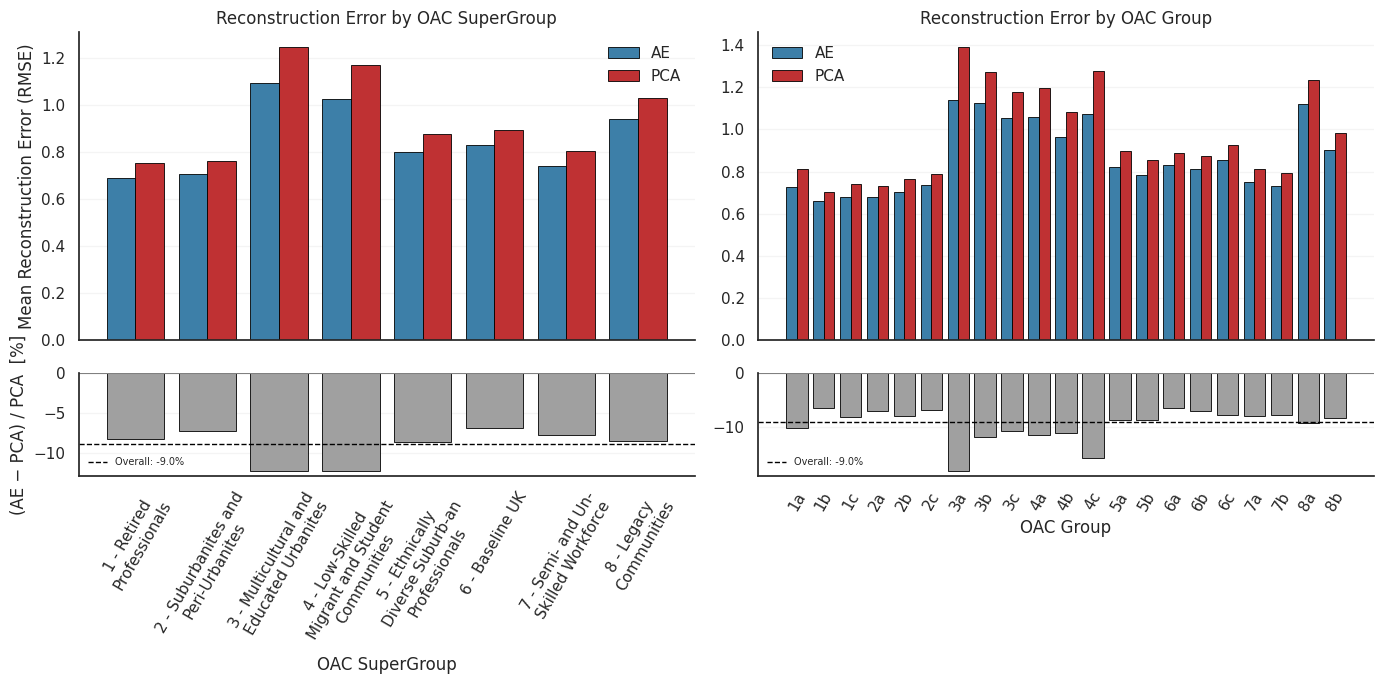

In [156]:
# Plot OAC Supergroup and Group
fig, axes = plot_side_by_side_charts(
    reco_err, 
    pca_reco_err, 
    "Supergroup_codename", 
    "Group", 
    "OAC SuperGroup", 
    "OAC Group", 
    "Reconstruction Error", 
    palette,
    bottleneck=bottleneck, 
    rotation=60,
    wrapped_labels=True
)
plt.savefig(f"plots/median_run_comparison_OAC_bottleneck_{bottleneck}.png", dpi=300, bbox_inches='tight')
plt.show()

## 4b. Global RMSE per Segment

Same groupings as above, but using **Global RMSE** = `sqrt(mean(RMSE²))` within each segment
rather than `mean(RMSE)`. This up-weights OAs with high error, revealing segments where
reconstruction quality is driven by outlier OAs.

## 5. Generate Spatial Data for Mapping

In [157]:
"""
This section compares reconstruction errors between AE (median run) and PCA at two geographic levels:
  1. Output Area (OA21CD)
  2. Middle Layer Super Output Area (MSOA21CD)

Steps:
- Merge and align error data
- Attach geographic boundaries (OAs and MSOAs)
- Calculate % difference in error
- Export the results to Parquet files for mapping
"""

# STEP 1: Merge reconstruction errors at OA level
merged = reco_err.merge(pca_reco_err, on="OA21CD", suffixes=("", "_pca"))

# Remove duplicated columns from pca_reco_err unless they're actual PCA error columns
merged = merged[[col for col in merged.columns if not col.endswith("_pca") or col.startswith("pca_err")]]

# STEP 2: Load OA boundaries and merge with error data
oa_gdf = gpd.read_parquet("../data/geofiles/oabounds_2021approx.parquet")[["OA", "geometry"]]
oa_gdf = oa_gdf.rename(columns={"OA": "OA21CD"})  # match OA code field name
merged = oa_gdf.merge(merged, on="OA21CD", how="right")  # keep only OAs with error data

# STEP 3: Calculate % difference in error
merged[f"perc_diff_{bottleneck}"] = (
    (merged[f"reco_err_{bottleneck}"] - merged[f"pca_err_{bottleneck}"]) / merged[f"pca_err_{bottleneck}"] * 100
)

# STEP 4: Format and export OA-level results
merged.set_index("OA21CD", inplace=True)
merged = merged.round(5)
merged.to_parquet(f"../data/plots/maps/median_run_error_diff_by_OA_{bottleneck}d.parquet")
print(f"Saved OA-level results to ../data/plots/maps/median_run_error_diff_by_OA_{bottleneck}d.parquet")

FileNotFoundError: [Errno 2] Failed to open local file '../data/plots/maps/median_run_error_diff_by_OA_100d.parquet'. Detail: [errno 2] No such file or directory

In [ ]:
# STEP 5: Aggregate to MSOA level
# Keep only error columns and MSOA codes for aggregation
merged_for_msoa = merged[[col for col in merged.columns if col.startswith("reco_err") or col.startswith("pca_err") or col == "MSOA21CD"]]

# Group by MSOA and compute mean error values
msoa = merged_for_msoa.groupby("MSOA21CD").mean().reset_index()

# Recompute % difference in error at MSOA level
msoa[f"perc_diff_{bottleneck}"] = (
    (msoa[f"reco_err_{bottleneck}"] - msoa[f"pca_err_{bottleneck}"]) / msoa[f"pca_err_{bottleneck}"] * 100
)

# STEP 6: Load MSOA boundaries and merge with error data
msoa_gdf = gpd.read_file(
    "../data/geofiles/Middle_layer_Super_Output_Areas_(December_2021)_Boundaries_EW_BFE_(V8)_and_RUC"
)[["MSOA21CD", "geometry"]]
msoa = msoa_gdf.merge(msoa, on="MSOA21CD", how="right")

# STEP 7: Export MSOA-level GeoDataFrame
msoa.to_parquet(f"../data/plots/maps/median_run_error_diff_by_MSOA_{bottleneck}d.parquet")
print(f"Saved MSOA-level results to ../data/plots/maps/median_run_error_diff_by_MSOA_{bottleneck}d.parquet")

In [ ]:
# Calculate quantiles for negative values in MSOA perc_diff to make figure 7

# Filter for negative values only
neg_values = msoa[msoa[f"perc_diff_{bottleneck}"] < 0][f"perc_diff_{bottleneck}"]
print(f"Only {len(msoa)-len(neg_values)} out of {len(msoa)} MSOAs have higher AE reconstruction error than PCA")

# Calculate quantile breaks
quantiles = neg_values.quantile([0, 0.2, 0.4, 0.6, 0.8, 1])
print(f"\nQuantiles for negative perc_diff_{bottleneck} values:\n{quantiles}")

## 6. Summary

In [ ]:
print("=" * 80)
print("SUMMARY: Error by Geography (Median-Error Run + Original Run)")
print("=" * 80)

print(f"\nConfiguration:")
print(f"  Bottleneck dimension: {bottleneck}D")
print(f"  Total retraining runs available: {n_runs}")
print(f"  Selected run: Run {median_run_idx} (median overall RMSE)")
print(f"  Selected run RMSE: {rmse_per_run[median_run_idx]*100:.4f}%")
print(f"  Mean RMSE across all runs: {rmse_per_run.mean()*100:.4f}% +/- {rmse_per_run.std()*100:.4f}%")

print(f"\nReconstruction Error Comparison:")
print(f"  {'':25s} {'Global RMSE':>12s}  {'Mean per-OA':>12s}")
print(f"  {'':-<25s} {'':-<12s}  {'':-<12s}")
print(f"  {'AE (median run)':<25s} {rmse_per_run[median_run_idx]*100:>11.4f}%  {mean_oa_rmse_per_run[median_run_idx]*100:>11.4f}%")
print(f"  {'AE (original run)':<25s} {global_rmse_orig:>11.4f}%  {mean_oa_rmse_orig:>11.4f}%")
print(f"  {'PCA':<25s} {global_rmse_pca:>11.4f}%  {mean_oa_rmse_pca:>11.4f}%")

print(f"\n  Improvement vs PCA (Global RMSE):")
print(f"    Median AE:   {(global_rmse_pca - rmse_per_run[median_run_idx]*100) / global_rmse_pca * 100:.2f}%")
print(f"    Original AE: {(global_rmse_pca - global_rmse_orig) / global_rmse_pca * 100:.2f}%")
print(f"  Improvement vs PCA (Mean per-OA RMSE):")
print(f"    Median AE:   {(mean_oa_rmse_pca - mean_oa_rmse_per_run[median_run_idx]*100) / mean_oa_rmse_pca * 100:.2f}%")
print(f"    Original AE: {(mean_oa_rmse_pca - mean_oa_rmse_orig) / mean_oa_rmse_pca * 100:.2f}%")

print(f"\nOutput Files:")
print(f"  Plots: plots/median_run_comparison_*.png")
print(f"  Spatial data: ../data/plots/maps/median_run_error_diff_*.parquet")
print("=" * 80)